# 中国主要城市公共预算收支数据分析

**数据来源**: 国家统计局 → 地区数据 → 主要城市年度数据  
**覆盖范围**: 36个主要城市, 2006-2024年

**分析内容**:
1. 数据加载与预览
2. 计算预算缺口 (gap) 和 gap_to_gdp
3. 计算 income/expend 年度增长率
4. 特定年份 gap_to_gdp 最大/最小城市排名
5. 全国 gap_to_gdp 趋势
6. 北上广深对比分析
7. 区域对比分析（珠三角 vs 长三角 + 房地产视角）
8. 热力图与增长率分布
9. 2022年排名总览

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
import warnings
warnings.filterwarnings('ignore')

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 150
matplotlib.rcParams['savefig.dpi'] = 150
matplotlib.rcParams['savefig.bbox'] = 'tight'

DATA_CLEAN = 'data_clean'
OUTPUT = 'output'
os.makedirs(OUTPUT, exist_ok=True)

## 1. 加载与预览数据

In [2]:
df = pd.read_excel(os.path.join(DATA_CLEAN, 'merged_data.xlsx'))

# city_code 统一转为字符串，避免后续匹配问题
df['city_code'] = df['city_code'].astype(str)

print(f'数据维度: {df.shape}')
print(f'城市数: {df["city"].nunique()}, 年份: {df["year"].min()}-{df["year"].max()}')
print(f'\n城市列表:')
print(df[['city_code', 'city']].drop_duplicates().sort_values('city_code').to_string(index=False))
df.head(10)

数据维度: (684, 10)
城市数: 36, 年份: 2006-2024

城市列表:
city_code city
   110000   北京
   120000   天津
   130100  石家庄
   140100   太原
   150100 呼和浩特
   210100   沈阳
   210200   大连
   220100   长春
   230100  哈尔滨
   310000   上海
   320100   南京
   330100   杭州
   330200   宁波
   340100   合肥
   350100   福州
   350200   厦门
   360100   南昌
   370100   济南
   370200   青岛
   410100   郑州
   420100   武汉
   430100   长沙
   440100   广州
   440300   深圳
   450100   南宁
   460100   海口
   500000   重庆
   510100   成都
   520100   贵阳
   530100   昆明
   540100   拉萨
   610100   西安
   620100   兰州
   630100   西宁
   640100   银川
   650100 乌鲁木齐


,city_code,city,year,income,expend,gdp,deposit,re_invest,re_sales_area,re_avg_price
0,110000,北京,2006,1117.1514,1296.8389,8618.9,8705.600000,1719.8650,2607.6178,8279.510134
1,110000,北京,2007,1492.6380,1649.5023,10730.4,9155.340000,1995.8206,2176.5727,11553.258478
2,110000,北京,2008,1837.3238,1959.2857,12167.6,11952.840000,1908.7387,1335.3700,12418.000000
3,110000,北京,2009,2026.8089,2319.3658,13335.7,14672.100000,2337.7124,2362.2500,13799.000000
4,110000,北京,2010,2353.9301,2717.3174,15420.2,17003.112186,2901.0700,1639.5300,17782.000000
5,110000,北京,2011,3006.2800,3245.2300,17653.3,19126.136991,3036.3118,1439.2018,16851.952937
6,110000,北京,2012,3314.9340,3685.3076,19568.3,21644.900000,3153.4419,1943.7367,17021.632611
7,110000,北京,2013,3661.1097,4173.6563,21746.0,23086.414992,3483.4045,1903.1124,18553.000000
8,110000,北京,2014,4027.1609,4524.6690,23577.5,24158.400000,3715.3341,1454.1935,18833.000000
9,110000,北京,2015,4723.8600,5737.7011,26034.1,23913.967000,4177.0481,1554.2463,22633.000000


In [3]:
print('描述性统计:')
df.describe().round(2)

描述性统计:


,year,income,expend,gdp,deposit,re_invest,re_sales_area,re_avg_price
count,684.00,682.00,682.00,682.00,679.00,666.00,665.00,665.00
mean,2015.00,897.23,1201.09,8119.62,6982.81,1225.93,1218.45,10503.16
std,5.48,1240.28,1529.22,8533.26,8568.85,1100.90,967.59,8190.11
min,2006.00,3.90,15.69,121.91,88.65,29.38,100.21,2021.99
25%,2010.00,219.70,342.11,2645.23,2050.72,408.17,585.92,5758.00
50%,2015.00,463.55,728.88,5491.37,4175.96,869.20,970.88,8344.00
75%,2020.00,1017.82,1342.73,10650.09,8540.25,1743.20,1554.25,12148.00
max,2024.00,8374.17,9874.84,53759.50,70398.15,6228.91,6711.00,58593.00


In [4]:
print('缺失值统计:')
df.isnull().sum()

缺失值统计:


city_code         0
city              0
year              0
income            2
expend            2
gdp               2
deposit           5
re_invest        18
re_sales_area    19
re_avg_price     19
dtype: int64

## 2. 计算预算缺口与比率

- `gap = expend - income` (单位: 亿元)  
- `gap_to_gdp = gap / gdp` (无量纲比率)

In [5]:
df['gap'] = df['expend'] - df['income']
df['gap_to_gdp'] = df['gap'] / df['gdp']

print('预算缺口 (gap) 统计 (亿元):')
print(df['gap'].describe().round(2))
print(f'\ngap_to_gdp 统计:')
print(df['gap_to_gdp'].describe().round(4))

预算缺口 (gap) 统计 (亿元):
count     682.00
mean      303.86
std       411.79
min      -107.98
25%        73.03
50%       190.02
75%       344.28
max      3025.66
Name: gap, dtype: float64

gap_to_gdp 统计:
count    680.0000
mean       0.0478
std        0.0536
min       -0.0191
25%        0.0208
50%        0.0366
75%        0.0578
max        0.4173
Name: gap_to_gdp, dtype: float64


## 3. 计算年度增长率

In [6]:
df = df.sort_values(['city_code', 'year'])
df['income_growth'] = df.groupby('city_code')['income'].pct_change() * 100
df['expend_growth'] = df.groupby('city_code')['expend'].pct_change() * 100

print('财政收入增长率(%):')
print(df['income_growth'].describe().round(2))
print(f'\n财政支出增长率(%):')
print(df['expend_growth'].describe().round(2))

财政收入增长率(%):
count    648.00
mean      12.66
std       15.95
min      -36.99
25%        3.59
50%       10.82
75%       19.50
max      172.51
Name: income_growth, dtype: float64

财政支出增长率(%):
count    648.00
mean      13.30
std       12.62
min      -21.85
25%        4.31
50%       12.34
75%       20.46
max       65.40
Name: expend_growth, dtype: float64


In [7]:
yearly_avg = df.groupby('year').agg(
    gap_to_gdp_mean=('gap_to_gdp', 'mean'),
    gap_to_gdp_median=('gap_to_gdp', 'median'),
    income_growth_mean=('income_growth', 'mean'),
    expend_growth_mean=('expend_growth', 'mean'),
).round(4)
yearly_avg

,gap_to_gdp_mean,gap_to_gdp_median,income_growth_mean,expend_growth_mean
year,,,,
2006,0.0247,0.0226,NaN,NaN
2007,0.0276,0.0219,34.2282,30.7231
2008,0.0307,0.0249,26.1894,26.0471
2009,0.0390,0.0350,12.4697,19.2987
2010,0.0343,0.0271,28.7428,25.2206
2011,0.0403,0.0285,31.7282,28.9613
2012,0.0424,0.0258,18.3617,17.0793
2013,0.0424,0.0301,15.7490,14.9429
2014,0.0417,0.0292,12.3045,10.2608


## 4. 特定年份 gap_to_gdp 最大/最小城市

展示 2006, 2010, 2014, 2018, 2022 年度上 `gap_to_gdp` 最大和最小的城市 (Top 3 / Bottom 3)。

In [8]:
target_years = [2006, 2010, 2014, 2018, 2022]
cols_show = ['city', 'income', 'expend', 'gdp', 'gap', 'gap_to_gdp']

all_ranks = []
for yr in target_years:
    yr_data = df[df['year'] == yr].dropna(subset=['gap_to_gdp'])
    top3 = yr_data.nlargest(3, 'gap_to_gdp')[cols_show].copy()
    bot3 = yr_data.nsmallest(3, 'gap_to_gdp')[cols_show].copy()
    top3['rank_type'] = '最大'
    bot3['rank_type'] = '最小'
    top3['year'] = yr
    bot3['year'] = yr
    all_ranks.append(top3)
    all_ranks.append(bot3)

    print(f'\n{"="*60}')
    print(f'  {yr}年 gap_to_gdp 排名')
    print(f'{"="*60}')
    print(f'\n  【最大 Top 3】')
    for _, r in top3.iterrows():
        print(f'    {r["city"]}: gap={r["gap"]:.2f}亿, gap/gdp={r["gap_to_gdp"]:.4f}')
    print(f'  【最小 Bottom 3】')
    for _, r in bot3.iterrows():
        print(f'    {r["city"]}: gap={r["gap"]:.2f}亿, gap/gdp={r["gap_to_gdp"]:.4f}')

rank_df = pd.concat(all_ranks, ignore_index=True)
rank_df.to_excel(os.path.join(OUTPUT, 'gap_to_gdp_top_bottom.xlsx'), index=False)
print(f'\n已保存: {OUTPUT}/gap_to_gdp_top_bottom.xlsx')


  2006年 gap_to_gdp 排名

  【最大 Top 3】
    西宁: gap=20.15亿, gap/gdp=0.0715
    重庆: gap=276.54亿, gap/gdp=0.0700
    兰州: gap=29.99亿, gap/gdp=0.0470
  【最小 Bottom 3】
    乌鲁木齐: gap=-7.50亿, gap/gdp=-0.0115
    杭州: gap=-25.91亿, gap/gdp=-0.0075
    福州: gap=-5.56亿, gap/gdp=-0.0033

  2010年 gap_to_gdp 排名

  【最大 Top 3】
    西宁: gap=74.40亿, gap/gdp=0.1184
    重庆: gap=756.96亿, gap/gdp=0.0925
    银川: gap=55.88亿, gap/gdp=0.0726
  【最小 Bottom 3】
    杭州: gap=-54.76亿, gap/gdp=-0.0092
    南京: gap=23.38亿, gap/gdp=0.0046
    福州: gap=14.60亿, gap/gdp=0.0047

  2014年 gap_to_gdp 排名

  【最大 Top 3】
    拉萨: gap=104.70亿, gap/gdp=0.3013
    西宁: gap=164.25亿, gap/gdp=0.1541
    重庆: gap=1382.37亿, gap/gdp=0.0927
  【最小 Bottom 3】
    杭州: gap=-66.14亿, gap/gdp=-0.0072
    厦门: gap=4.45亿, gap/gdp=0.0014
    南京: gap=17.72亿, gap/gdp=0.0020

  2018年 gap_to_gdp 排名

  【最大 Top 3】
    拉萨: gap=190.01亿, gap/gdp=0.3514
    西宁: gap=204.53亿, gap/gdp=0.1590
    重庆: gap=2275.41亿, gap/gdp=0.1041
  【最小 Bottom 3】
    杭州: gap=-107.98亿, gap/gdp=-0.0

## 5. 全国 gap_to_gdp 趋势

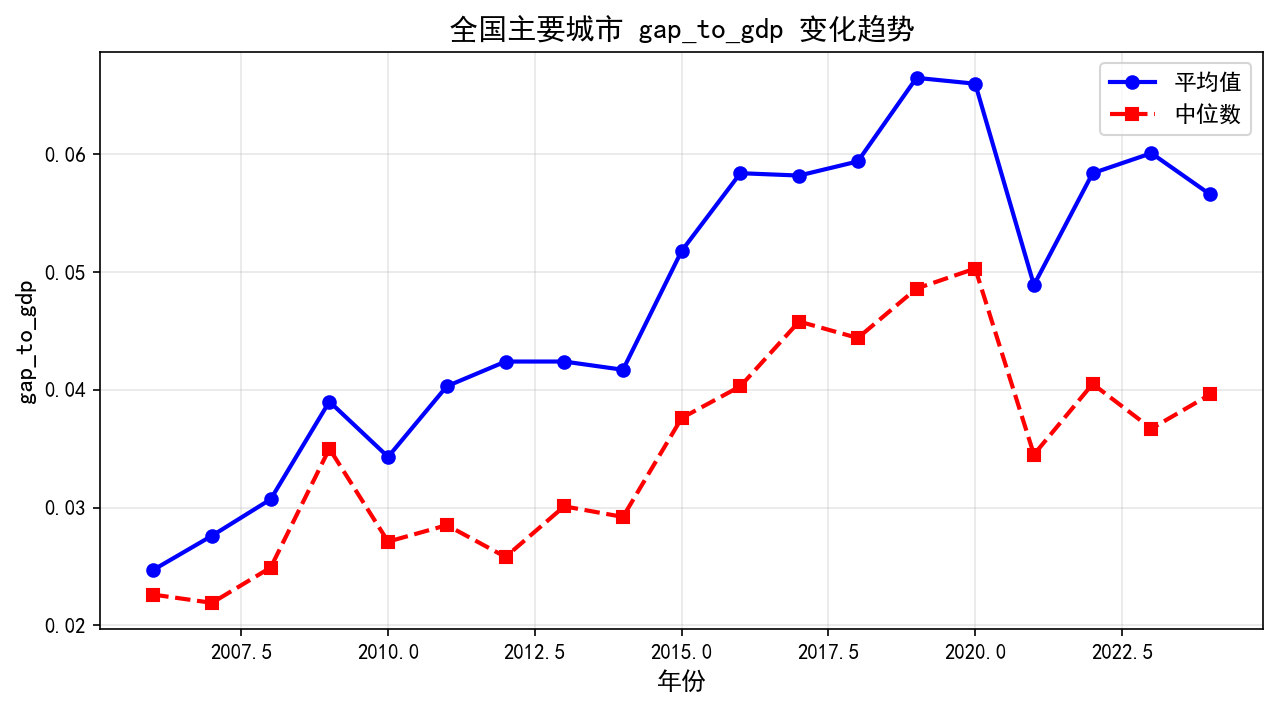

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly_avg.index, yearly_avg['gap_to_gdp_mean'], 'b-o', label='平均值', linewidth=2)
ax.plot(yearly_avg.index, yearly_avg['gap_to_gdp_median'], 'r--s', label='中位数', linewidth=2)
ax.set_xlabel('年份', fontsize=12)
ax.set_ylabel('gap_to_gdp', fontsize=12)
ax.set_title('全国主要城市 gap_to_gdp 变化趋势', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.savefig(os.path.join(OUTPUT, 'fig1_gap_to_gdp_trend.png'))
plt.show()

### 结果解读

从全国平均趋势看，`gap_to_gdp` 在样本期内总体呈上升趋势，说明主要城市财政支出相对财政收入和经济规模的扩张更快。尤其在经济波动和地方稳增长压力较大的阶段，财政支出的刚性往往强于收入端的修复速度，因此预算缺口容易抬升。

与此同时，中位数与平均值的差异也提示我们：不同城市之间存在明显分化。如果平均值高于中位数较多，通常说明部分高缺口城市在拉高整体水平；这意味着全国趋势应与城市分布、区域差异结合起来理解，而不能仅看单一均值指标。

## 6. 北上广深对比分析

In [10]:
tier1 = ['北京', '上海', '广州', '深圳']
df_t1 = df[df['city'].isin(tier1)].copy()

# 验证数据
print('北上广深数据量验证:')
print(df_t1.groupby('city')['year'].agg(['count', 'min', 'max']))
print(f'\n总行数: {len(df_t1)}')

北上广深数据量验证:
      count   min   max
city                   
上海       19  2006  2024
北京       19  2006  2024
广州       19  2006  2024
深圳       19  2006  2024

总行数: 76


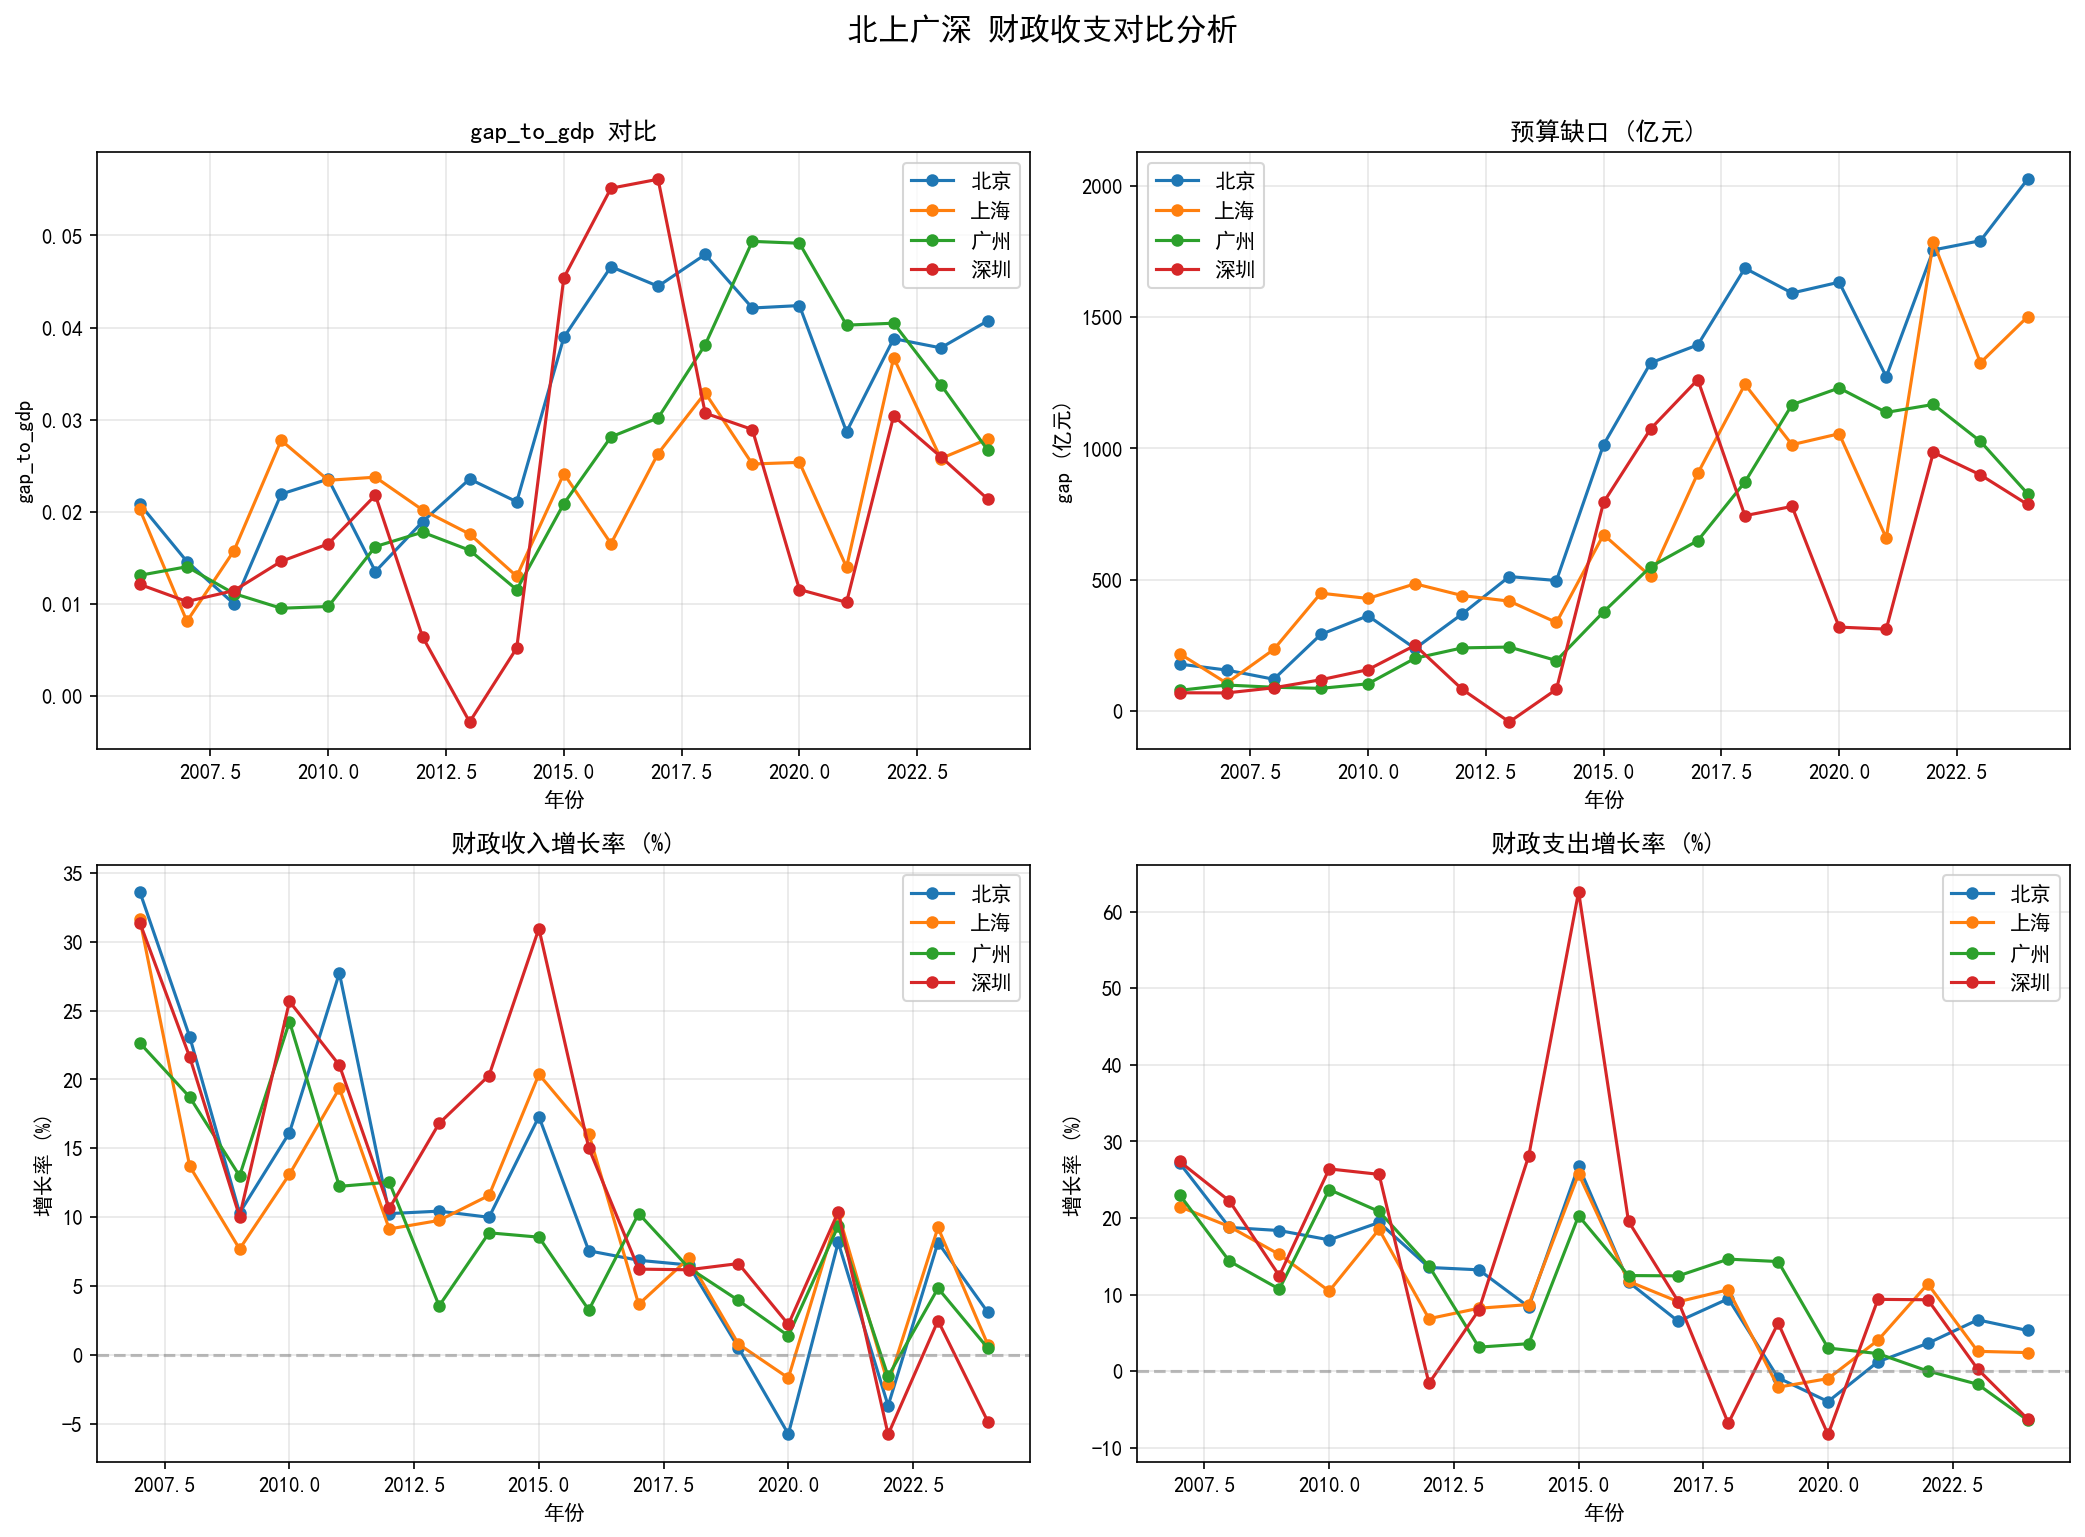

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# gap_to_gdp
ax = axes[0, 0]
for city in tier1:
    cd = df_t1[df_t1['city'] == city].sort_values('year')
    ax.plot(cd['year'], cd['gap_to_gdp'], '-o', label=city, markersize=5)
ax.set_title('gap_to_gdp 对比')
ax.set_xlabel('年份'); ax.set_ylabel('gap_to_gdp')
ax.legend(); ax.grid(True, alpha=0.3)

# gap 绝对值
ax = axes[0, 1]
for city in tier1:
    cd = df_t1[df_t1['city'] == city].sort_values('year')
    ax.plot(cd['year'], cd['gap'], '-o', label=city, markersize=5)
ax.set_title('预算缺口 (亿元)')
ax.set_xlabel('年份'); ax.set_ylabel('gap (亿元)')
ax.legend(); ax.grid(True, alpha=0.3)

# 收入增长率
ax = axes[1, 0]
for city in tier1:
    cd = df_t1[df_t1['city'] == city].sort_values('year')
    ax.plot(cd['year'], cd['income_growth'], '-o', label=city, markersize=5)
ax.set_title('财政收入增长率 (%)')
ax.set_xlabel('年份'); ax.set_ylabel('增长率 (%)')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.legend(); ax.grid(True, alpha=0.3)

# 支出增长率
ax = axes[1, 1]
for city in tier1:
    cd = df_t1[df_t1['city'] == city].sort_values('year')
    ax.plot(cd['year'], cd['expend_growth'], '-o', label=city, markersize=5)
ax.set_title('财政支出增长率 (%)')
ax.set_xlabel('年份'); ax.set_ylabel('增长率 (%)')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.legend(); ax.grid(True, alpha=0.3)

fig.suptitle('北上广深 财政收支对比分析', fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT, 'fig2_tier1_comparison.png'))
plt.show()

### 结果解读

北上广深的比较显示，一线城市虽然都具备较强的财政收入能力，但预算缺口与增长节奏仍存在明显差异。一般来说，北京和上海财政规模更大，缺口绝对值也可能更高；但如果其 GDP 同时足够大，那么 `gap_to_gdp` 未必最高。深圳通常表现出更强的财政自给能力，而广州则可能在部分年份面临更高的支出压力。

从增长率角度看，一线城市的收入与支出并非总是同步变化。当收入增速放缓而支出仍保持较快增长时，预算缺口就会扩大；相反，如果收入修复快于支出扩张，则 `gap_to_gdp` 会有所改善。因此，这一部分更适合用来观察城市财政弹性和抗冲击能力的差异。

## 7. 区域对比分析：珠三角 vs 长三角

根据数据集中可用城市进行分组：

| 区域 | 城市 |
|------|------|
| 长三角 | 上海、南京、杭州、宁波、合肥 |
| 珠三角 | 广州、深圳 |

本节整合财政、GDP、房地产等多维度进行区域对比。

In [12]:
# 区域分组定义
region_map = {
    '长三角': ['上海', '南京', '杭州', '宁波', '合肥'],
    '珠三角': ['广州', '深圳'],
}

df['region'] = '其他'
for region, cities in region_map.items():
    df.loc[df['city'].isin(cities), 'region'] = region

# 验证分组
print('区域分组验证:')
for region, cities in region_map.items():
    sub = df[df['region'] == region]
    print(f'  {region}: {sub["city"].unique().tolist()}, {len(sub)} 行')
print(f'  其他: {df[df["region"]=="其他"]["city"].nunique()} 个城市, {len(df[df["region"]=="其他"])} 行')

区域分组验证:
  长三角: ['上海', '南京', '杭州', '宁波', '合肥'], 95 行
  珠三角: ['广州', '深圳'], 38 行
  其他: 29 个城市, 551 行


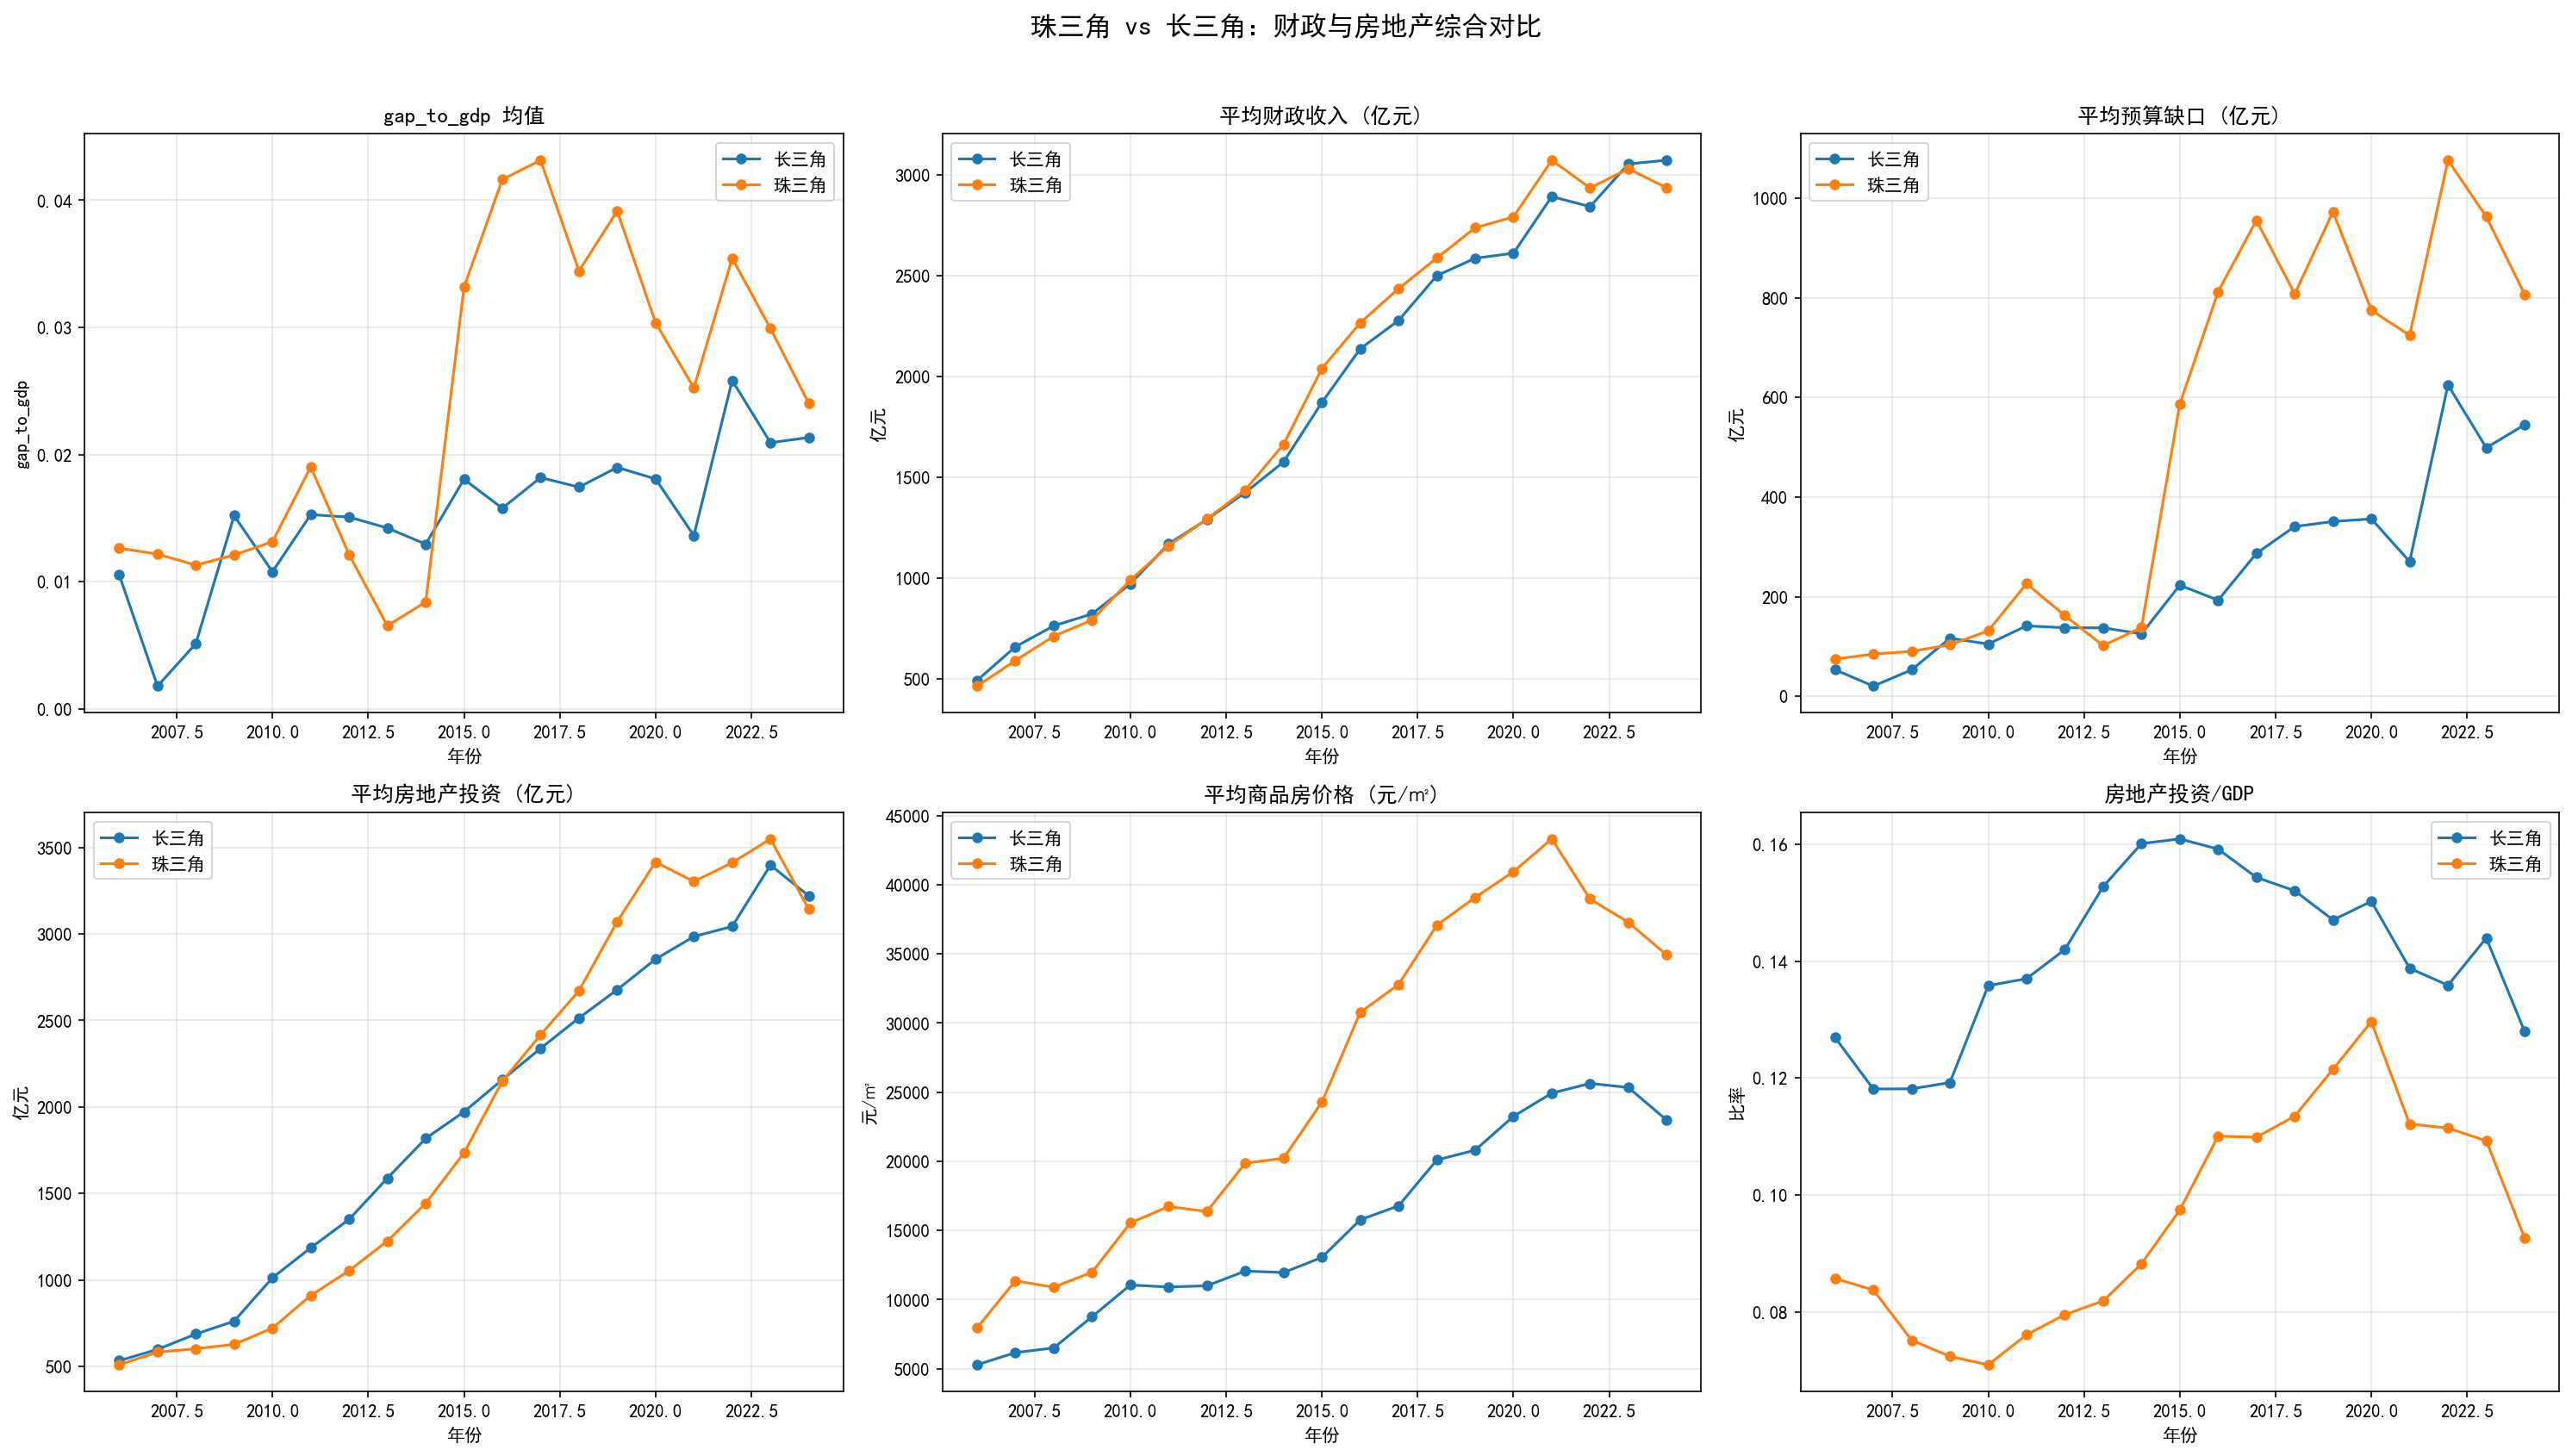

In [13]:
# 按区域-年份聚合
region_yr = df[df['region'] != '其他'].groupby(['region', 'year']).agg(
    gap_to_gdp_mean  = ('gap_to_gdp', 'mean'),
    income_mean      = ('income', 'mean'),
    expend_mean      = ('expend', 'mean'),
    gap_mean         = ('gap', 'mean'),
    gdp_mean         = ('gdp', 'mean'),
    re_invest_mean   = ('re_invest', 'mean'),
    re_avg_price_mean= ('re_avg_price', 'mean'),
).reset_index()

region_yr['re_invest_to_gdp'] = region_yr['re_invest_mean'] / region_yr['gdp_mean']

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
colors = {'长三角': '#1f77b4', '珠三角': '#ff7f0e'}

plot_configs = [
    (axes[0,0], 'gap_to_gdp_mean',    'gap_to_gdp 均值',         'gap_to_gdp'),
    (axes[0,1], 'income_mean',         '平均财政收入 (亿元)',      '亿元'),
    (axes[0,2], 'gap_mean',            '平均预算缺口 (亿元)',      '亿元'),
    (axes[1,0], 're_invest_mean',      '平均房地产投资 (亿元)',    '亿元'),
    (axes[1,1], 're_avg_price_mean',   '平均商品房价格 (元/㎡)',  '元/㎡'),
    (axes[1,2], 're_invest_to_gdp',    '房地产投资/GDP',           '比率'),
]

for ax, col, title, ylabel in plot_configs:
    for region in ['长三角', '珠三角']:
        rd = region_yr[region_yr['region'] == region].sort_values('year')
        ax.plot(rd['year'], rd[col], '-o', label=region, color=colors[region], markersize=5)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('年份')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle('珠三角 vs 长三角：财政与房地产综合对比', fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT, 'fig3_region_comparison.png'))
plt.show()

### 结果解读

从区域比较看，珠三角与长三角在财政和房地产变量上的变化趋势并不完全同步。珠三角样本城市数量较少，但广州和深圳的财政收入基础较强、经济密度较高，因此在不少年份表现出更低的 `gap_to_gdp`；长三角则覆盖城市更多，区域内部差异也更明显，因此其均值更容易受到不同城市结构特征的共同影响。

将房地产变量一并纳入后，可以看到区域财政差异并不仅仅来自财政口径本身，还受到房地产投资强度、房价水平以及经济规模的共同影响。这说明，区域财政压力具有明显的“产业结构 + 城市能级 + 房地产周期”叠加效应。

## 8. 房地产视角下的财政分析

从城市房地产开发和销售角度分析 gap_to_gdp 的地区差异和时序特征。

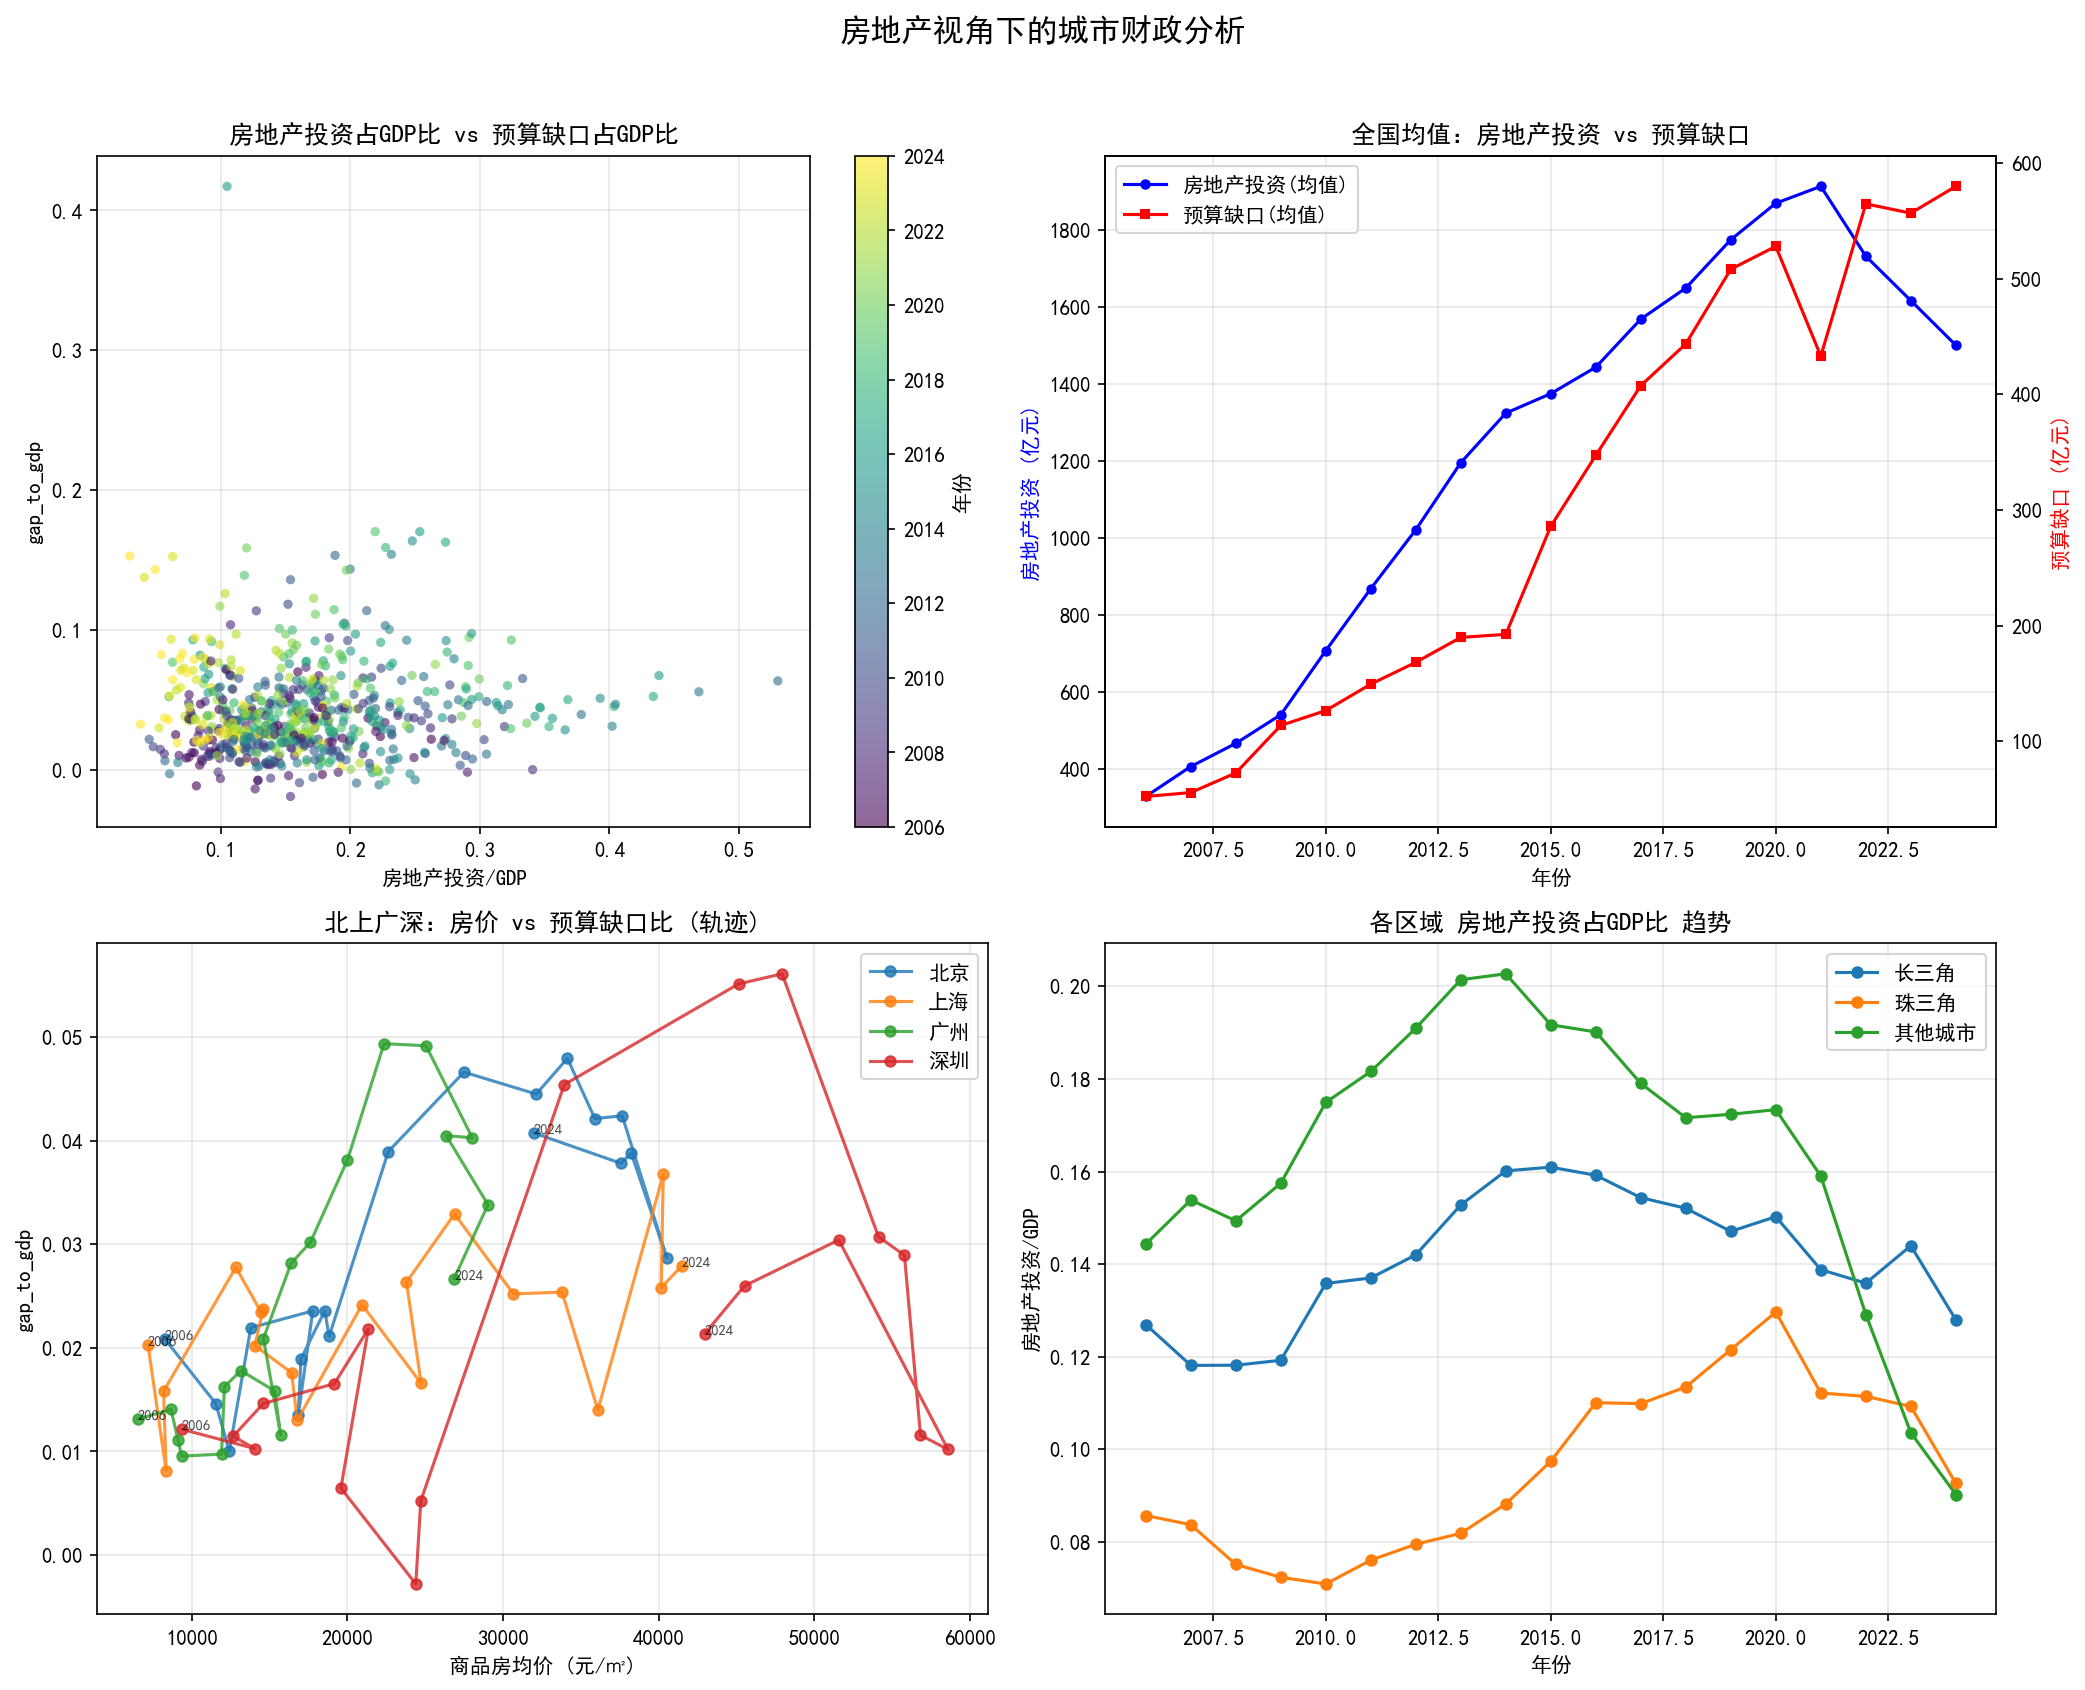

In [14]:
df['re_invest_to_gdp'] = df['re_invest'] / df['gdp']

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# (1) 散点图：房地产投资/GDP vs gap_to_gdp，按年份着色
ax = axes[0, 0]
mask = df['re_invest_to_gdp'].notna() & df['gap_to_gdp'].notna()
sc = ax.scatter(df.loc[mask, 're_invest_to_gdp'], df.loc[mask, 'gap_to_gdp'],
                c=df.loc[mask, 'year'], cmap='viridis', alpha=0.6, s=20, edgecolors='none')
plt.colorbar(sc, ax=ax, label='年份')
ax.set_xlabel('房地产投资/GDP')
ax.set_ylabel('gap_to_gdp')
ax.set_title('房地产投资占GDP比 vs 预算缺口占GDP比')
ax.grid(True, alpha=0.3)

# (2) 双轴：全国平均 房地产投资 vs 预算缺口 时序趋势
ax = axes[0, 1]
yr_re = df.groupby('year').agg(
    re_invest_mean=('re_invest', 'mean'),
    gap_mean=('gap', 'mean'),
).dropna()
ax2 = ax.twinx()
l1, = ax.plot(yr_re.index, yr_re['re_invest_mean'], 'b-o', label='房地产投资(均值)', ms=4)
l2, = ax2.plot(yr_re.index, yr_re['gap_mean'], 'r-s', label='预算缺口(均值)', ms=4)
ax.set_xlabel('年份')
ax.set_ylabel('房地产投资 (亿元)', color='b')
ax2.set_ylabel('预算缺口 (亿元)', color='r')
ax.set_title('全国均值：房地产投资 vs 预算缺口')
ax.legend(handles=[l1, l2], loc='upper left')
ax.grid(True, alpha=0.3)

# (3) 北上广深：房价 vs gap_to_gdp 散点图，带年份标注
ax = axes[1, 0]
for city in tier1:
    cd = df[(df['city'] == city) & df['re_avg_price'].notna() & df['gap_to_gdp'].notna()].sort_values('year')
    ax.plot(cd['re_avg_price'], cd['gap_to_gdp'], '-o', label=city, alpha=0.8, markersize=5)
    # 标注首尾年份
    if len(cd) > 0:
        ax.annotate(str(cd['year'].iloc[0]), (cd['re_avg_price'].iloc[0], cd['gap_to_gdp'].iloc[0]),
                    fontsize=7, alpha=0.7)
        ax.annotate(str(cd['year'].iloc[-1]), (cd['re_avg_price'].iloc[-1], cd['gap_to_gdp'].iloc[-1]),
                    fontsize=7, alpha=0.7)
ax.set_xlabel('商品房均价 (元/㎡)')
ax.set_ylabel('gap_to_gdp')
ax.set_title('北上广深：房价 vs 预算缺口比 (轨迹)')
ax.legend()
ax.grid(True, alpha=0.3)

# (4) 各区域 房地产投资/GDP 趋势
ax = axes[1, 1]
for region_name, color in [('长三角', '#1f77b4'), ('珠三角', '#ff7f0e'), ('其他', '#2ca02c')]:
    rd = df[df['region'] == region_name].dropna(subset=['re_invest', 'gdp'])
    if len(rd) == 0:
        continue
    yr_agg = rd.groupby('year').apply(
        lambda x: x['re_invest'].sum() / x['gdp'].sum(), include_groups=False
    )
    label = region_name if region_name != '其他' else '其他城市'
    ax.plot(yr_agg.index, yr_agg.values, '-o', label=label, color=color, markersize=5)
ax.set_xlabel('年份')
ax.set_ylabel('房地产投资/GDP')
ax.set_title('各区域 房地产投资占GDP比 趋势')
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle('房地产视角下的城市财政分析', fontsize=15, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT, 'fig4_real_estate_analysis.png'))
plt.show()

## 9. 各城市 gap_to_gdp 热力图

### 结果解读

房地产相关图形表明，房地产投资、房价与财政缺口之间存在一定联系，但这种关系并不是简单的一一对应。整体来看，房地产投资占 GDP 的比重较高的时期，往往伴随着地方财政收入扩张能力增强，但这种支撑在不同城市、不同阶段表现出明显差异。

对于北上广深而言，房价水平本身并不直接决定 `gap_to_gdp`，更关键的是房地产景气度如何通过土地、税收和相关产业链影响财政收入。当房地产市场降温时，财政收入端承压，而刚性支出难以及时回落，预算缺口就更容易扩大。

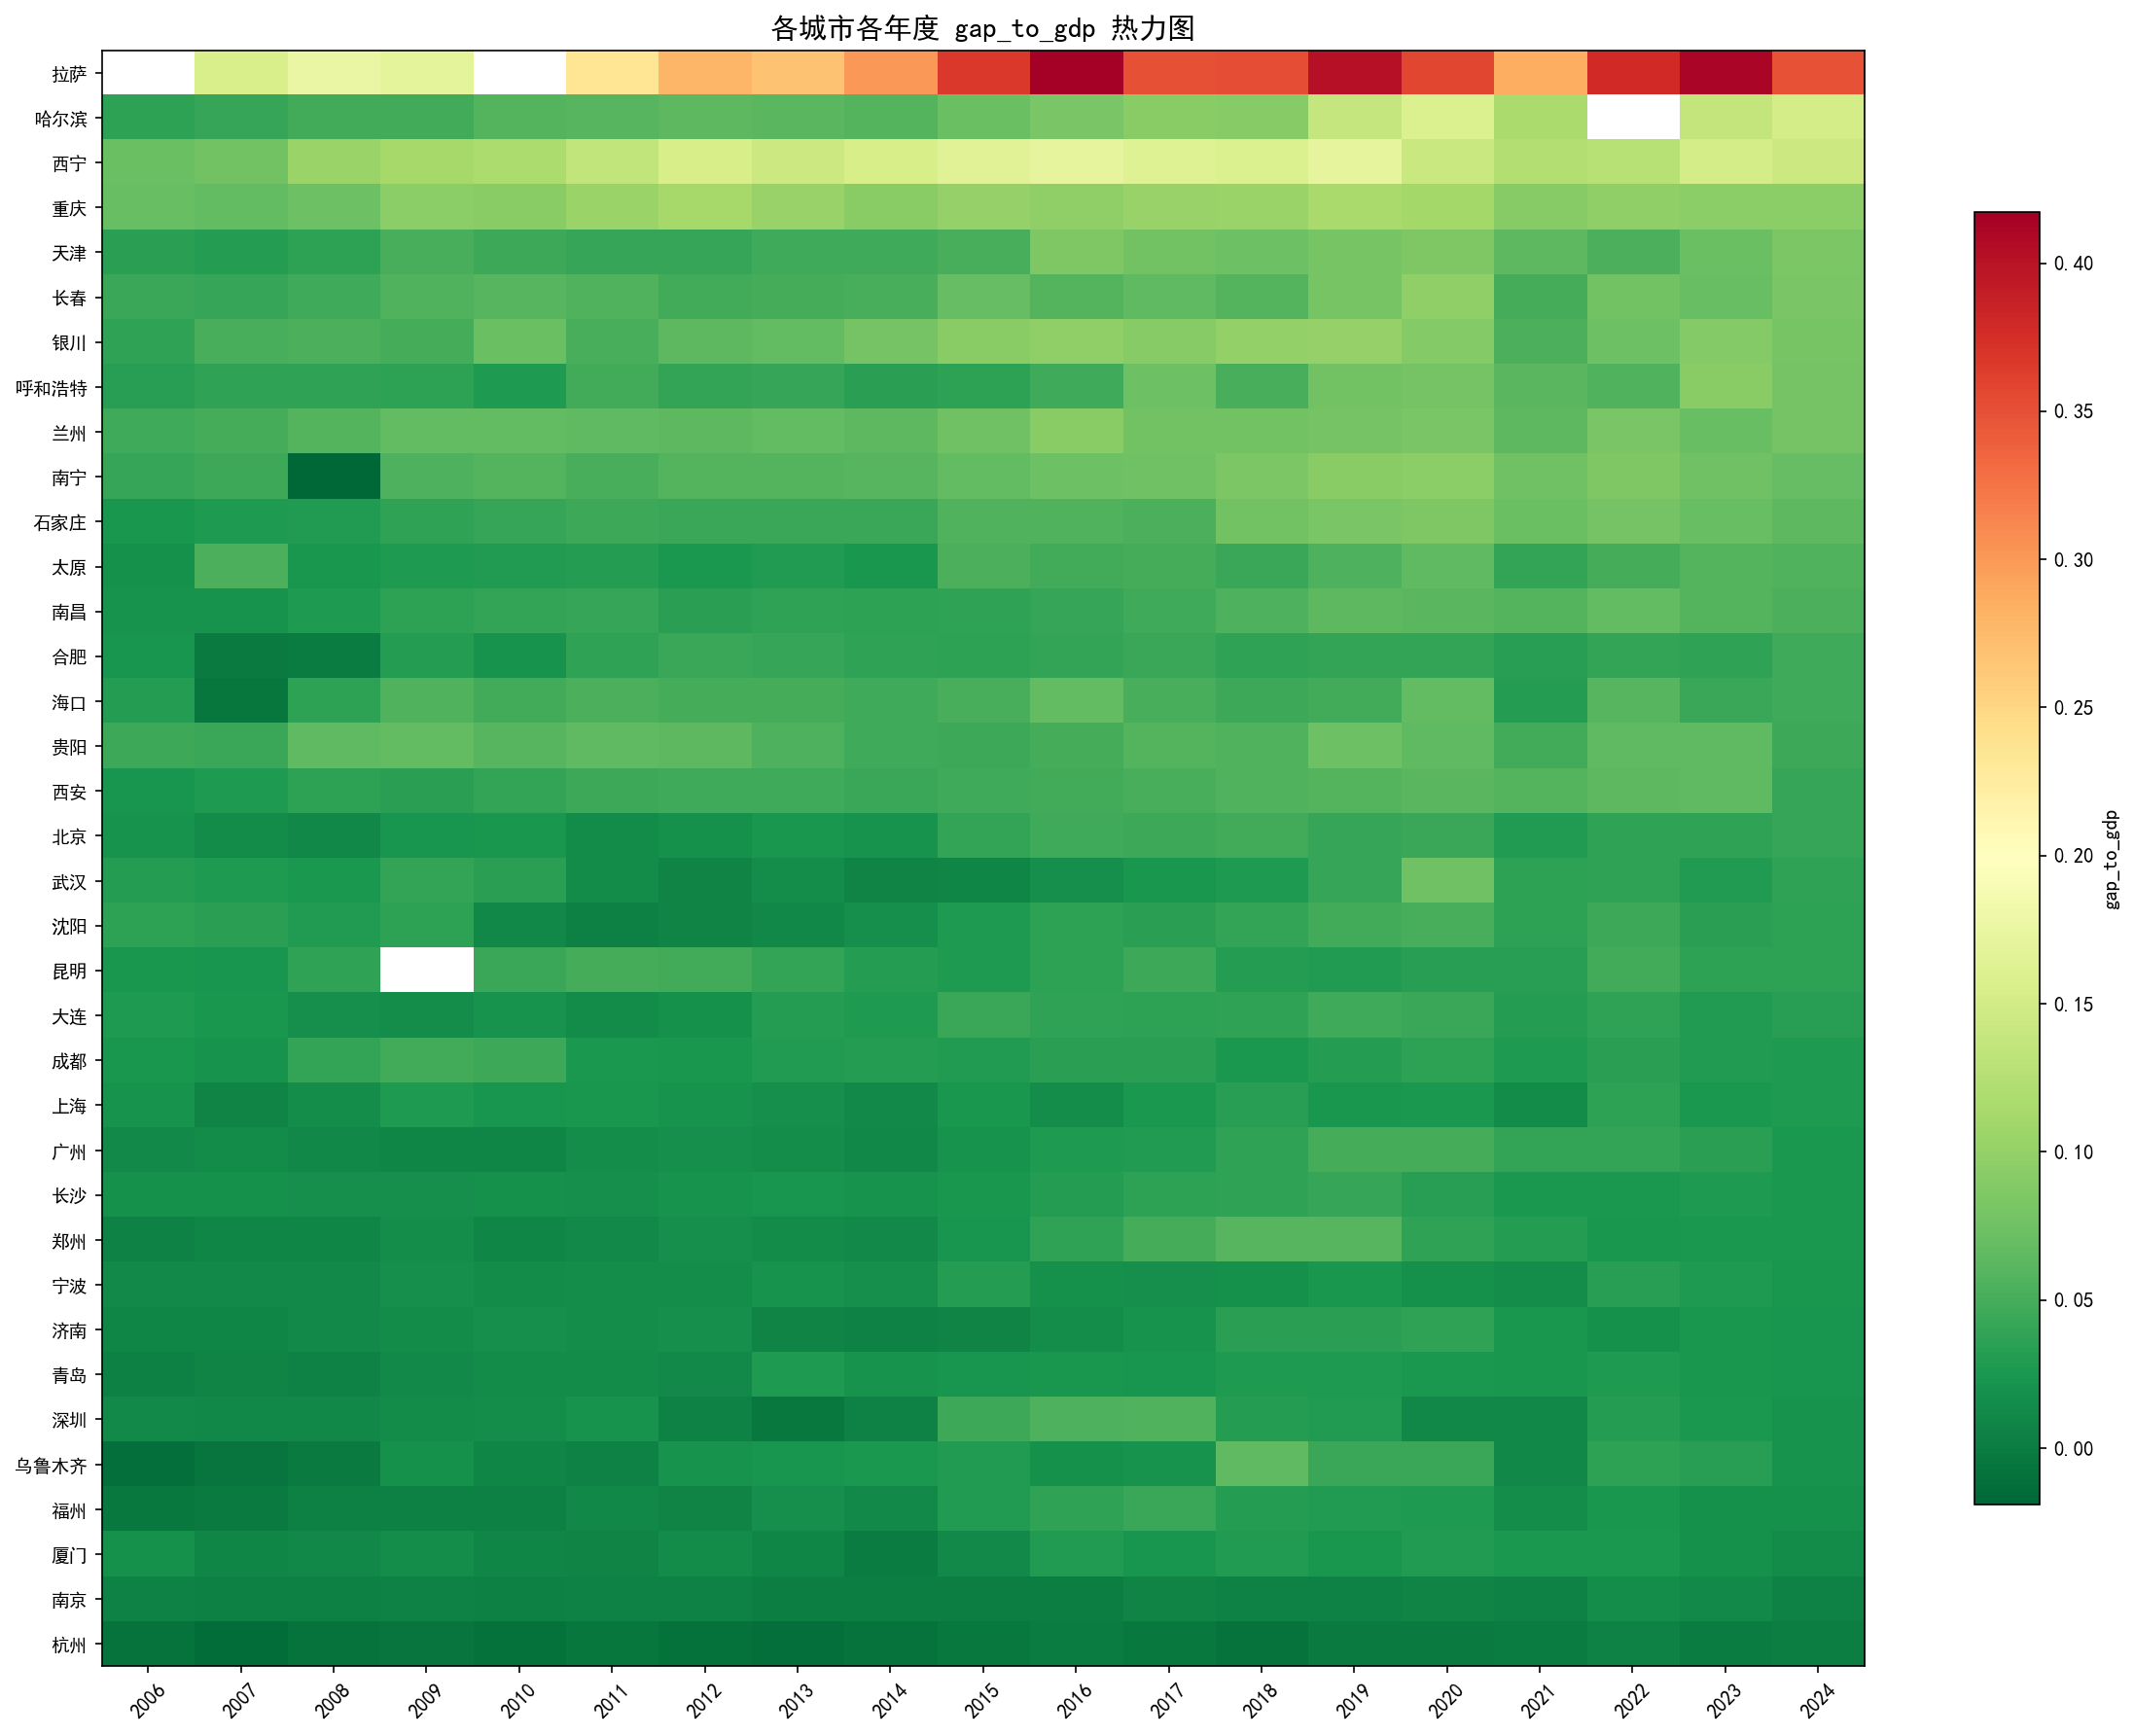

In [15]:
pivot = df.pivot_table(index='city', columns='year', values='gap_to_gdp')
latest_col = pivot.columns[-1]
pivot = pivot.sort_values(by=latest_col, ascending=False)

fig, ax = plt.subplots(figsize=(16, 12))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
plt.colorbar(im, ax=ax, label='gap_to_gdp', shrink=0.8)
ax.set_title('各城市各年度 gap_to_gdp 热力图', fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT, 'fig5_heatmap.png'))
plt.show()

### 结果解读

箱线图显示，不同年份城市财政收入与支出增长率的离散程度并不一致。某些年份箱体更高、须更长，说明城市之间的增长分化更明显；而当箱体收窄时，则意味着各城市的财政扩张节奏相对接近。

从整体上看，支出增长率的波动通常小于收入增长率的大幅异常波动，但在经济承压阶段，收入端更容易受到地产、产业和税基变化的影响，因此收入增长的不确定性往往会进一步传导到预算缺口上。

## 10. 增长率分布 (箱线图)

### 结果解读

热力图能够帮助识别哪些城市长期处于高财政压力区间，哪些城市则长期保持较低的 `gap_to_gdp`。如果某个城市在多数年份都处于偏高颜色区间，说明其财政缺口并非短期波动，而可能具有更稳定的结构性特征；反之，若只在个别年份显著升高，则更可能与阶段性冲击、投资扩张或宏观周期有关。

从全国分布看，城市间的财政压力并不是同步变化的，而是存在明显的地区差异和分层特征。这也说明，单纯使用全国平均值并不足以描述全部情况，区域比较和个别城市轨迹分析同样重要。

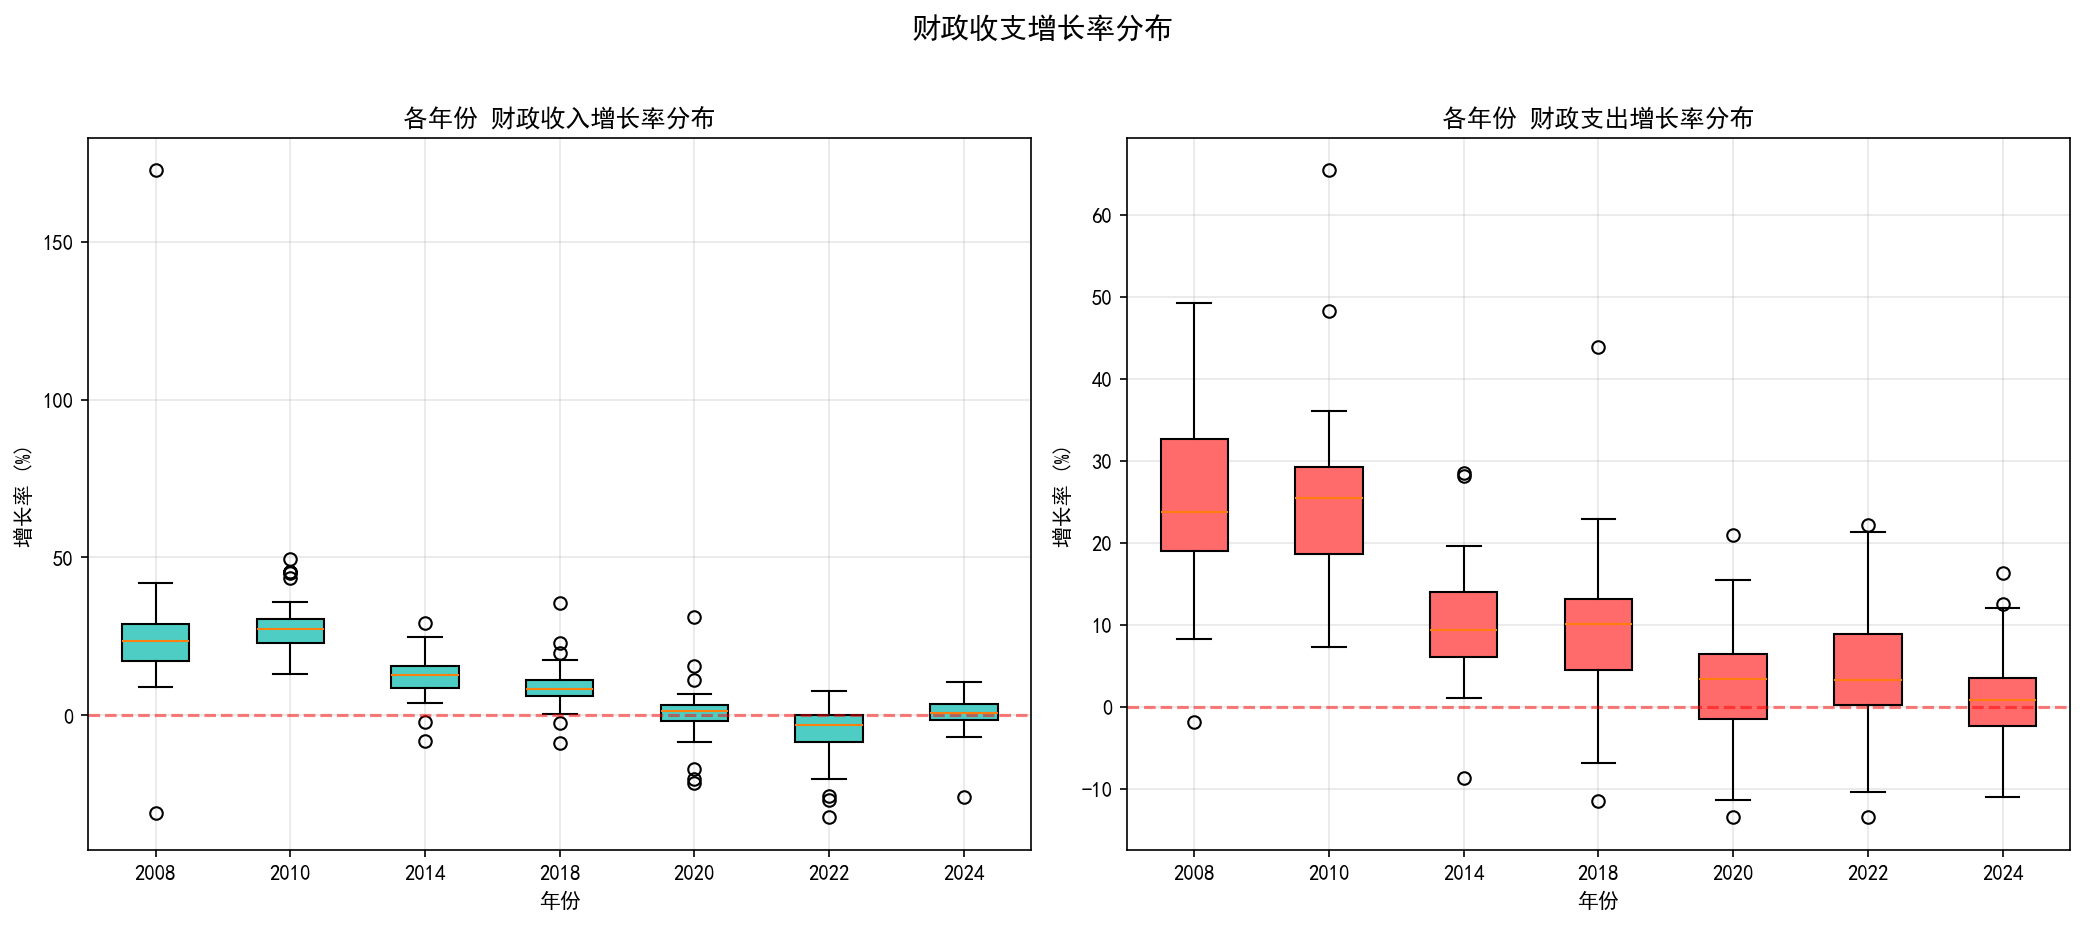

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sel_years = [2008, 2010, 2014, 2018, 2020, 2022, 2024]
df_sel = df[df['year'].isin(sel_years)]

ax = axes[0]
data_inc = [df_sel[df_sel['year'] == yr]['income_growth'].dropna().values for yr in sel_years]
bp = ax.boxplot(data_inc, labels=sel_years, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#4ECDC4')
ax.set_title('各年份 财政收入增长率分布', fontsize=12)
ax.set_xlabel('年份'); ax.set_ylabel('增长率 (%)')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

ax = axes[1]
data_exp = [df_sel[df_sel['year'] == yr]['expend_growth'].dropna().values for yr in sel_years]
bp = ax.boxplot(data_exp, labels=sel_years, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#FF6B6B')
ax.set_title('各年份 财政支出增长率分布', fontsize=12)
ax.set_xlabel('年份'); ax.set_ylabel('增长率 (%)')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)

fig.suptitle('财政收支增长率分布', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT, 'fig6_growth_boxplot.png'))
plt.show()

## 11. 2022年各城市 gap_to_gdp 排名

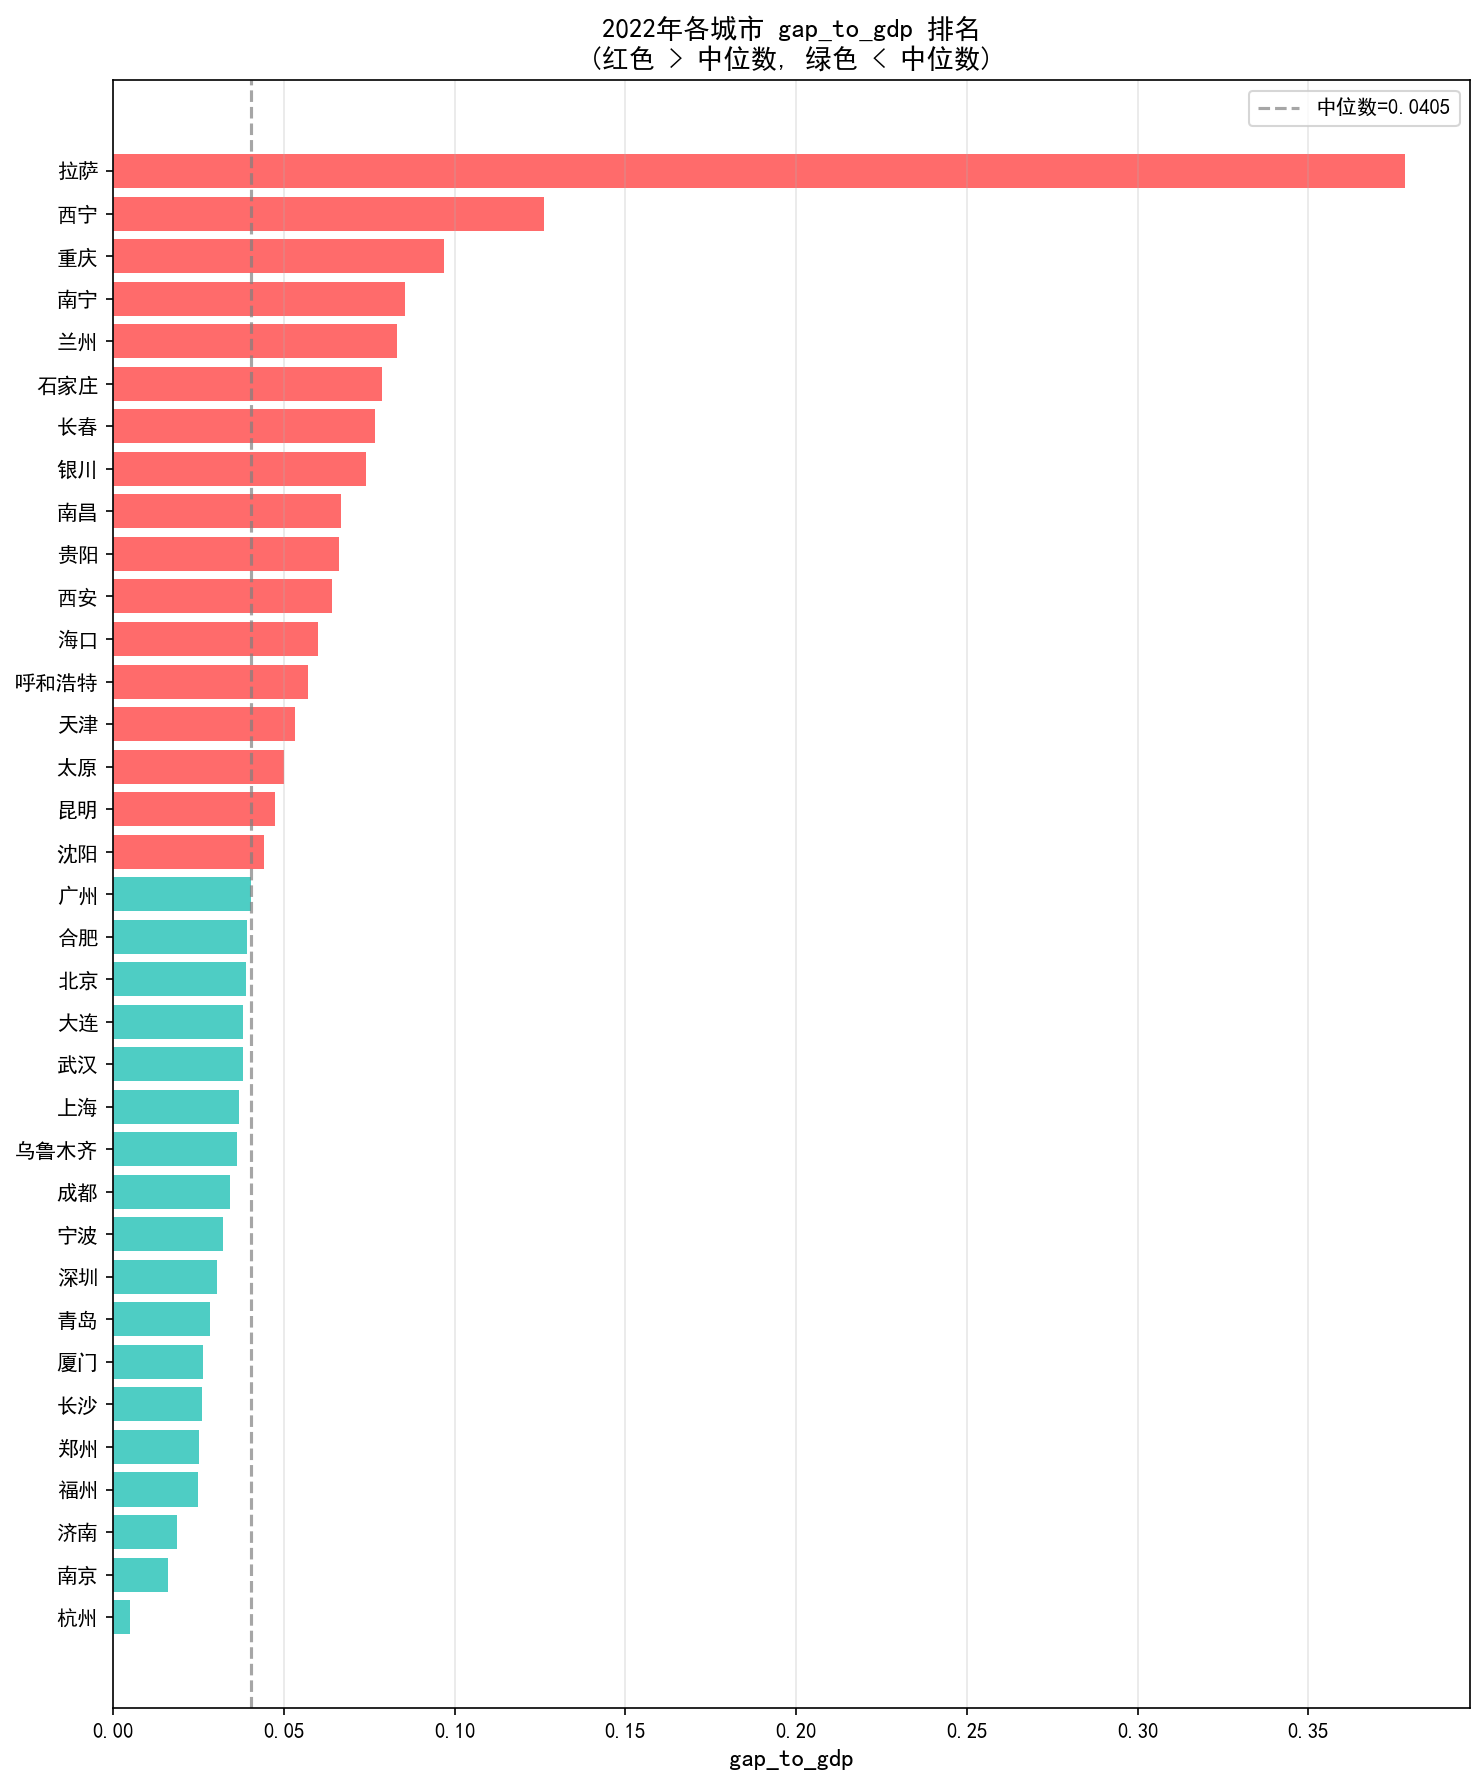

In [17]:
df_2022 = df[df['year'] == 2022].dropna(subset=['gap_to_gdp']).sort_values('gap_to_gdp', ascending=True)
median_val = df_2022['gap_to_gdp'].median()

fig, ax = plt.subplots(figsize=(10, 12))
bar_colors = ['#FF6B6B' if v > median_val else '#4ECDC4' for v in df_2022['gap_to_gdp']]
ax.barh(df_2022['city'], df_2022['gap_to_gdp'], color=bar_colors)
ax.axvline(x=median_val, color='gray', linestyle='--', alpha=0.7, label=f'中位数={median_val:.4f}')
ax.set_xlabel('gap_to_gdp', fontsize=12)
ax.set_title('2022年各城市 gap_to_gdp 排名\n(红色 > 中位数, 绿色 < 中位数)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT, 'fig7_2022_bar.png'))
plt.show()

### 结果解读

从 2022 年的横向排名来看，城市之间的财政压力差异仍然较大。`gap_to_gdp` 较高的城市，通常表现为财政支出明显快于财政收入扩张，且本地经济总量对缺口的吸收能力相对较弱；而排名靠后的城市，则往往具有更强的财政收入基础或更高的经济规模支撑。

需要注意的是，`gap_to_gdp` 反映的是预算缺口相对经济规模的压力，而不是绝对财政实力。一个经济体量很大的城市，即使预算缺口绝对额较高，只要 GDP 足够大，其 `gap_to_gdp` 仍可能保持在较低水平。因此，在解读排序时，应当同时结合 `gap` 的绝对值和 `gdp` 的规模来看。

## 12. 保存所有分析数据

In [18]:
df.to_excel(os.path.join(DATA_CLEAN, 'analysis_data.xlsx'), index=False)

growth_summary = df.groupby('city').agg(
    income_growth_mean=('income_growth', 'mean'),
    income_growth_std=('income_growth', 'std'),
    expend_growth_mean=('expend_growth', 'mean'),
    expend_growth_std=('expend_growth', 'std'),
    gap_to_gdp_mean=('gap_to_gdp', 'mean'),
).round(4).sort_values('gap_to_gdp_mean', ascending=False)
growth_summary.to_excel(os.path.join(OUTPUT, 'growth_rate.xlsx'))

yearly_avg.to_excel(os.path.join(OUTPUT, 'yearly_summary.xlsx'))

print('所有分析数据已保存！')
print(f'\noutput/ 目录:')
for f in sorted(os.listdir(OUTPUT)):
    size_kb = os.path.getsize(os.path.join(OUTPUT, f)) / 1024
    print(f'  {f:45s} {size_kb:8.1f} KB')

所有分析数据已保存！

output/ 目录:
  fig1_gap_to_gdp_trend.png                         71.4 KB
  fig2_tier1_comparison.png                        438.5 KB
  fig3_region_comparison.png                       362.2 KB
  fig4_real_estate_analysis.png                    447.6 KB
  fig5_heatmap.png                                 111.1 KB
  fig6_growth_boxplot.png                           73.3 KB
  fig7_2022_bar.png                                104.0 KB
  gap_to_gdp_top_bottom.xlsx                         7.0 KB
  growth_rate.xlsx                                   6.7 KB
  yearly_summary.xlsx                                5.5 KB
